# [실습 10-2] 사전학습 모델 전이학습 — 처음부터 학습 vs 거인의 어깨

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (**GPU 권장**) |
| 본문 연계 | 10.3 전이학습 |
| 선수 실습 | [실습 10-1] (CNN 구조·학습 루프 재사용) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 꽃 데이터(약 220MB)·MobileNetV2 가중치 다운로드 |

꽃 사진 3,700장 — 딥러닝치고는 **아주 적은** 데이터다.
소형 CNN을 처음부터 학습시킨 결과와, 대규모 데이터로
미리 배운 MobileNetV2를 빌려 온 결과를 비교한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch10/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from utils import plot_style

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("TensorFlow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else
      "없음 — Colab 메뉴 [런타임 유형 변경]에서 T4 선택")

Cloning into 'ai-labs'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 144 (delta 66), reused 130 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 728.42 KiB | 2.70 MiB/s, done.
Resolving deltas: 100% (66/66), done.
/content/ai-labs
Python 3.12.13
TensorFlow 2.20.0
GPU: /physical_device:GPU:0


### [셀 1] 꽃 데이터(tf_flowers) 로드와 분할 📖

In [2]:
data_dir = keras.utils.get_file(
    "flower_photos", extract=True, origin=(
        "https://storage.googleapis.com/"
        "download.tensorflow.org/example_images/"
        "flower_photos.tgz"))
data_dir = Path(data_dir) / "flower_photos"

SIZE = (224, 224)               # MobileNetV2 입력 크기
train_ds, val_ds = keras.utils \
    .image_dataset_from_directory(
        data_dir, validation_split=0.2,
        subset="both", seed=42,
        image_size=SIZE, batch_size=32)
CLASSES = train_ds.class_names
print("클래스:", CLASSES)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.
클래스: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**핵심 포인트**
- 5종의 꽃, 약 3,700장 — 클래스당 700장 수준. 10.3 〈사전학습과 파인튜닝〉 판단 기준표의 "데이터 적음 + 사전학습 도메인과 유사" 칸에 해당한다.
- 이미지를 224×224로 통일하는 이유: 빌려 올 MobileNetV2가 그 크기로 배웠기 때문이다.

기대 출력: 훈련 2,936장 / 검증 734장, 클래스 5종

### [셀 2] Before — 소형 CNN을 처음부터 📖

In [3]:
scratch = keras.Sequential([
    keras.layers.Input(SIZE + (3,)),
    keras.layers.Rescaling(1 / 255),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(5, activation="softmax"),
])
scratch.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
hist_s = scratch.fit(train_ds, epochs=10,
                     validation_data=val_ds, verbose=2)

Epoch 1/10
92/92 - 18s - 194ms/step - accuracy: 0.4033 - loss: 1.8131 - val_accuracy: 0.5068 - val_loss: 1.1494
Epoch 2/10
92/92 - 5s - 56ms/step - accuracy: 0.5947 - loss: 0.9979 - val_accuracy: 0.5654 - val_loss: 1.0957
Epoch 3/10
92/92 - 6s - 68ms/step - accuracy: 0.7105 - loss: 0.7620 - val_accuracy: 0.5831 - val_loss: 1.0386
Epoch 4/10
92/92 - 5s - 58ms/step - accuracy: 0.8409 - loss: 0.4614 - val_accuracy: 0.5749 - val_loss: 1.3477
Epoch 5/10
92/92 - 7s - 74ms/step - accuracy: 0.9285 - loss: 0.2479 - val_accuracy: 0.5627 - val_loss: 1.3350
Epoch 6/10
92/92 - 5s - 55ms/step - accuracy: 0.9574 - loss: 0.1423 - val_accuracy: 0.5654 - val_loss: 1.7213
Epoch 7/10
92/92 - 5s - 59ms/step - accuracy: 0.9728 - loss: 0.1029 - val_accuracy: 0.5695 - val_loss: 2.0966
Epoch 8/10
92/92 - 10s - 110ms/step - accuracy: 0.9734 - loss: 0.0949 - val_accuracy: 0.5504 - val_loss: 2.2724
Epoch 9/10
92/92 - 6s - 68ms/step - accuracy: 0.9905 - loss: 0.0483 - val_accuracy: 0.5668 - val_loss: 2.1223
Epoch 

**핵심 포인트**
- 실습 10-1의 CNN 축소판이다 — 구조는 옳지만, 3,700장으로 "꽃의 특징"을 밑바닥부터 배워야 한다.
- 5에포크 안에 과적합 조짐(훈련↑·검증 정체)이 보이는 것도 관찰 포인트다(6장 재소환).

### [셀 3] After — MobileNetV2 동결 + 분류층 교체 📖

In [4]:
base = keras.applications.MobileNetV2(
    input_shape=SIZE + (3,),
    include_top=False,          # 분류층은 떼고
    weights="imagenet")         # 배운 눈은 가져온다
base.trainable = False          # 안전한 시작값 ①: 동결

transfer = keras.Sequential([
    keras.layers.Input(SIZE + (3,)),
    # MobileNetV2 전처리: 0~255 → -1~1
    keras.layers.Rescaling(1 / 127.5, offset=-1),
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(5, activation="softmax"),
])
transfer.compile(
    optimizer="adam",           # 동결 특징추출 단계:
    # 보호할 사전학습 가중치가 없고 새 분류층만 학습하므로
    # 기본 학습률(1e-3)을 쓴다. 1/10 학습률은 해동
    # 파인튜닝 단계의 규칙이다([심화 1]의 자리).
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
hist_t = transfer.fit(train_ds, epochs=10,
                      validation_data=val_ds, verbose=2)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
92/92 - 53s - 574ms/step - accuracy: 0.6914 - loss: 0.8158 - val_accuracy: 0.8474 - val_loss: 0.4713
Epoch 2/10
92/92 - 6s - 64ms/step - accuracy: 0.8532 - loss: 0.4125 - val_accuracy: 0.8706 - val_loss: 0.4135
Epoch 3/10
92/92 - 5s - 57ms/step - accuracy: 0.8903 - loss: 0.3369 - val_accuracy: 0.8719 - val_loss: 0.3922
Epoch 4/10
92/92 - 7s - 71ms/step - accuracy: 0.9040 - loss: 0.2800 - val_accuracy: 0.8828 - val_loss: 0.3606
Epoch 5/10
92/92 - 10s - 112ms/step - accuracy: 0.9125 - loss: 0.2584 - val_accuracy: 0.9019 - val_loss: 0.3357
Epoch 6/10
92/92 - 5s - 56ms/step - accuracy: 0.9247 - loss: 0.2230 - val_accuracy: 0.8896 - val_loss: 0.3393
Epoch 7/10
92/92 - 10s - 114ms/step - accuracy: 0.9305 - loss: 0.1972 - val_accuracy: 0.8910 - val_loss: 0.3213
Epoch 8/10
92/92 - 11s - 119ms/step - accuracy: 0.9384 - loss: 0.1951 - val_accuracy: 0.8978 - val_loss: 0.3286
Epoch 9/10
92/92 - 10s - 114ms/step - accuracy: 0.9438 - loss: 

**핵심 포인트**
- 본문 10.3의 '안전한 시작값'의 핵심은 **동결 한 줄**이다: `base.trainable = False`(수천 장 이하면 사전학습 특징을 그대로 빌린다). 새 분류층만 학습하므로 옵티마이저는 **기본 학습률**을 쓴다 — **학습률 1/10은 동결을 푸는 해동(파인튜닝) 단계의 규칙**([심화 1]의 자리)이지 이 단계의 규칙이 아니다.
- 학습되는 것은 마지막 분류층뿐 — 수백만 장으로 배운 "보는 눈"(base)은 그대로 빌린다. "거인의 어깨" 그 자체.

실패 시 대처: 가중치 다운로드 실패 시 재실행. 메모리 부족 시 `batch_size=16`으로 축소.

### [셀 4] 두 모델 비교 📖

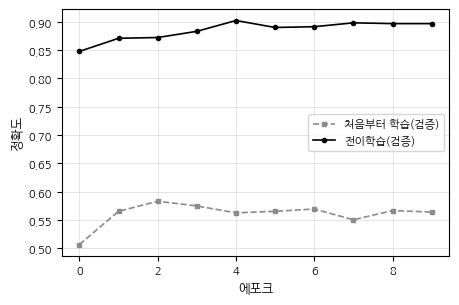

최종 검증 정확도 — 처음부터: 0.564 / 전이학습: 0.896


In [5]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(hist_s.history["val_accuracy"], "--",
        color="#8c8c8c", lw=1.2, marker="s", ms=3,
        label="처음부터 학습(검증)")
ax.plot(hist_t.history["val_accuracy"], "-",
        color="black", lw=1.2, marker="o", ms=3,
        label="전이학습(검증)")
ax.set_xlabel("에포크")
ax.set_ylabel("정확도")
ax.legend()
plt.show()
print(f"최종 검증 정확도 — 처음부터: "
      f"{hist_s.history['val_accuracy'][-1]:.3f} / "
      f"전이학습: "
      f"{hist_t.history['val_accuracy'][-1]:.3f}")

**핵심 포인트**
- 기대 구도: 처음부터 학습 약 60% 내외 vs 전이학습 약 90% 내외 — 소규모 데이터에서 전이학습의 압도적 우위.
- 전이학습 곡선은 **1에포크부터 높게 시작**한다 — 이미 특징을 아는 감정사가 품종 이름만 새로 외우는 셈이다.

### [보조 1] 데이터 증강 파이프라인 (10.3 연동)

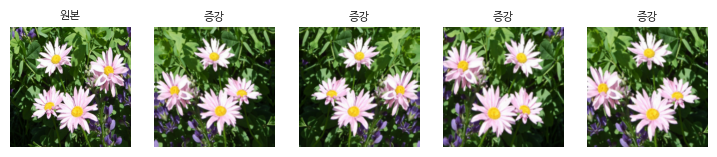

In [6]:
aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])
imgs, _ = next(iter(train_ds))
fig, axes = plt.subplots(1, 5, figsize=(9, 2))
axes[0].imshow(imgs[0].numpy().astype("uint8"))
axes[0].set_title("원본", fontsize=8)
for ax in axes[1:]:
    ax.imshow(aug(imgs[:1])[0].numpy().astype("uint8"))
    ax.set_title("증강", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()
# 한 장이 여러 장이 된다 — 소규모 데이터의 표준 처방

### [심화 1] 미세 조정 — 상위 층 일부 해동 (연습문제 연계)

In [7]:
# TODO: 동결을 일부 풀고(위쪽 30개 층) 학습률을
#       다시 1/10로 낮춰 이어서 학습해 보자.
#       "해동 범위 ↑ = 유연성 ↑ 그러나 과적합 위험 ↑"
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
transfer.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # 또 1/10
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
# hist_f = transfer.fit(train_ds, epochs=3,
#                       validation_data=val_ds)

---
## 마무리

- 데이터가 적을 때의 정석: **동결 + 분류층 교체(기본 학습률)** — 사실상 `base.trainable = False` 한 줄의 결정이다. 낮은 학습률(1/10)은 그것으로 부족할 때 [심화 1]의 **해동(파인튜닝) 단계**에서 더한다.
- 전이학습은 "이미 배운 표현"의 재사용이다 — 8.5 표현학습 브리지가 여기서 실전이 된다.
- 판단 기준(10.3 표): 데이터 규모와 도메인 유사도가 동결 범위를 정한다 — [심화 1]에서 직접 검증할 수 있다.

**연습문제 연계**: [응용] 시나리오별 전이 전략 선택 문항의 판단 근거가 [셀 4]와 [심화 1] 결과다.

**다음 실습**: [실습 10-3] 확산 모델 체험 — 저장소 전용 (`lab-10-03_diffusion-demo.ipynb`)